# Comparación de modelos

El siguiente documento presenta los entrenamientos de varios modelos usando datos agregados. este sirve como punto de partida y comparación para arquitecturas más complejas o que empleen datos crudos.

Los modelos empleados son: 
- Convolutional Neural Network (CNN)
    - Descripcion
- Long Short-Term Memory (LSTM)
    - Descripcion
- Recurrent Neural Network (RNN)
    - Descripcion
- Deep Neural Network (DNN)
    - Descripcion


El conjunto de datos empleado se componen de 17.248 filas y 20 columnas. En este cada fila corresponde a una medición del experimento 1st_test, es el primero de 3 experimentos que conforman el dataset [IMS-Rexnord Bearing](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) realizado en la universidad de Cincinnati cuyos investigadores dispusieron datos sobre viabraciones elementos rodantes. Las columnas corresponde a diferentes parametros y estadísticos, algunos de ellos son: amplitud maxima, amplitud promedio, error cuadrático medio, varianza, desviación estándar, entre otros.

# Tabla de resultados


| MODELO       | PRECISIÓN    | RECALL       |  F1 - SCORE  | 
|--------------|--------------|--------------|--------------|
| CNN          | 0.96         | 0.98         | 0.97         |
| RNN          | 0.98         | 1.00         | 0.99         |
| LSTM         | 0.98         | 1.00         | 0.99         |
| DNN          | 0.96         | 0.98         | 0.97         |


# Declaracion de librerias


In [1]:
# LIBRERIAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

# MK - CNN


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns

2026-04-03 01:03:55.392932: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-03 01:03:55.393082: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-03 01:03:55.427433: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-03 01:03:55.496275: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-03 01:03:56.459821: W tensorflow/compiler/tf2

In [22]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

## Separación del dataset

In [13]:
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = df["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df[df["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X.append(matriz)
    
    # target del experimento
    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2156, 8, 21)
(2156,)


In [14]:
#codificacion de clases 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

num_classes = len(le.classes_)

In [25]:
np.unique(y, return_counts=True)

(array(['Early', 'Inminent failure', 'Normal', 'Suspect'], dtype='<U16'),
 array([ 150,   56,  900, 1050]))

In [6]:
# escalado de features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(X.shape)

# division en train y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1724, 8, 21), (1724,), (432, 8, 21), (432,))

## Declaración del modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout

model = Sequential([

    Conv1D(
        filters=32,
        kernel_size=2,
        activation="relu",
        input_shape=(X.shape[1], X.shape[2])
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=2,
        activation="relu"
    ),

    Flatten(),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

2026-03-27 09:30:38.936250: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-27 09:30:39.090171: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-27 09:30:39.092283: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Entrenamiento

In [9]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/lib/cuda"

In [10]:
!export XLA_FLAGS=--xla_gpu_cuda_data_dir=/usr/lib/cuda

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50


2026-03-27 09:30:40.435934: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2026-03-27 09:30:41.846698: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fad94b0a3f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-27 09:30:41.846736: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2026-03-27 09:30:41.858399: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774621841.973758   66188 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


87/87 [==============================] - 4s 13ms/step - loss: 0.7684 - accuracy: 0.6534 - val_loss: 0.4692 - val_accuracy: 0.8377
Epoch 2/50
87/87 [==============================] - 0s 4ms/step - loss: 0.3852 - accuracy: 0.8550 - val_loss: 0.3812 - val_accuracy: 0.8667
Epoch 3/50
87/87 [==============================] - 0s 4ms/step - loss: 0.3128 - accuracy: 0.8832 - val_loss: 0.3627 - val_accuracy: 0.8638
Epoch 4/50
87/87 [==============================] - 0s 5ms/step - loss: 0.2642 - accuracy: 0.8912 - val_loss: 0.3352 - val_accuracy: 0.8725
Epoch 5/50
87/87 [==============================] - 0s 5ms/step - loss: 0.2335 - accuracy: 0.9130 - val_loss: 0.2928 - val_accuracy: 0.8899
Epoch 6/50
87/87 [==============================] - 0s 5ms/step - loss: 0.2181 - accuracy: 0.9130 - val_loss: 0.2733 - val_accuracy: 0.8986
Epoch 7/50
87/87 [==============================] - 0s 5ms/step - loss: 0.1966 - accuracy: 0.9304 - val_loss: 0.2540 - val_accuracy: 0.9101
Epoch 8/50
87/87 [============

In [12]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

tf.random.normal([1000,1000]) @ tf.random.normal([1000,1000])

TensorFlow: 2.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<tf.Tensor: shape=(1000, 1000), dtype=float32, numpy=
array([[ 25.946268  , -49.90523   ,  18.422834  , ...,   9.874031  ,
        -15.859683  , -17.878372  ],
       [ 30.078222  ,  34.020687  ,   5.5360312 , ..., -32.212067  ,
          8.542616  ,  31.83374   ],
       [ -2.7609184 ,  -9.428331  , -42.0711    , ...,  27.562765  ,
         38.307785  ,  38.38106   ],
       ...,
       [-43.86514   , -17.01585   ,  -5.753897  , ..., -14.288779  ,
          0.21678339, -17.531132  ],
       [-32.711678  , -29.134577  ,  -1.857698  , ...,  -5.866938  ,
         28.19914   ,  47.99137   ],
       [ -4.9845734 , -88.47235   ,   0.9890269 , ...,  36.543053  ,
          1.5214622 ,  -2.1871674 ]], dtype=float32)>

In [13]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/lib/cuda"

import os
print(os.environ.get("XLA_FLAGS"))

# luego de esto reetablecer el kernel para que tome la nueva variable de entorno

--xla_gpu_cuda_data_dir=/usr/lib/cuda


## Evaluación

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.9652777777777778
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.92      1.00      0.96        11
          Normal       0.95      0.98      0.96       180
         Suspect       0.99      0.94      0.96       211

        accuracy                           0.97       432
       macro avg       0.95      0.98      0.97       432
    weighted avg       0.97      0.97      0.97       432



In [15]:
# muestra los valores unicos de y_test para verificar las clases presentes

print(np.unique(y_test))

[0 1 2 3]


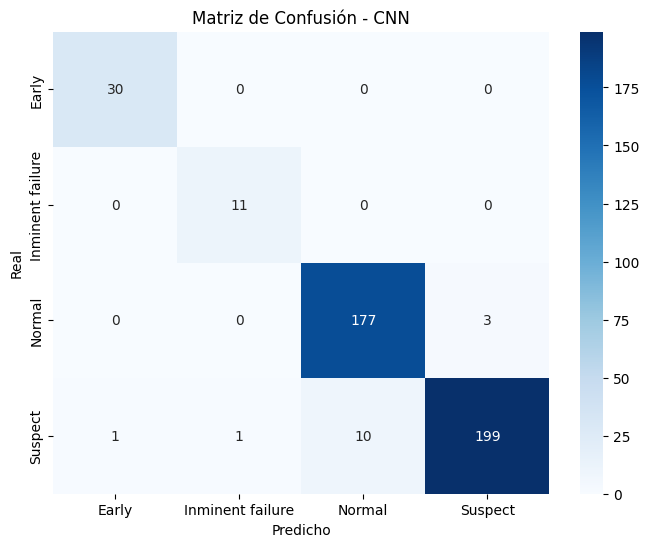

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues",
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - CNN")

plt.show()

# RNN


In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

In [19]:
df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

In [20]:
features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = sorted(df["archivo"].unique())

X = []
y = []

for exp in experimentos:

    bloque = df[df["archivo"] == exp].sort_values("canal")

    matriz = bloque[features].values   # (8 sensores × features)

    X.append(matriz.flatten())         # vectorizar sensores

    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

In [21]:
# estandarizar features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

## Separación del dataset

In [22]:

window = 100

X_seq = []
y_seq = []

for i in range(len(X) - window):

    X_seq.append(X[i:i+window])
    y_seq.append(y[i+window])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)

(2056, 100, 168)


## Codificacion de clases 

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_seq = le.fit_transform(y_seq)

num_classes = len(le.classes_)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    stratify=y_seq,
    random_state=42
)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    stratify=y_seq,
    random_state=42
)

## Declaración del modelo

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model = Sequential([

    SimpleRNN(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.3),

    SimpleRNN(32),

    Dense(64, activation="relu"),

    Dense(num_classes, activation="softmax")

])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Entrenamiento

In [27]:
!ln -s /usr/lib/nvidia-cuda-toolkit/libdevice/libdevice.10.bc ./libdevice.10.bc

ln: failed to create symbolic link './libdevice.10.bc': File exists


In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/40


2026-03-27 09:33:18.808176: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 88368000 exceeds 10% of free system memory.
2026-03-27 09:33:18.943751: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 88368000 exceeds 10% of free system memory.


165/165 [==============================] - 16s 78ms/step - loss: 0.4093 - accuracy: 0.8608 - val_loss: 0.1854 - val_accuracy: 0.9483
Epoch 2/40
165/165 [==============================] - 12s 75ms/step - loss: 0.0708 - accuracy: 0.9833 - val_loss: 0.1038 - val_accuracy: 0.9787
Epoch 3/40
165/165 [==============================] - 12s 75ms/step - loss: 0.0422 - accuracy: 0.9886 - val_loss: 0.0474 - val_accuracy: 0.9848
Epoch 4/40
165/165 [==============================] - 13s 77ms/step - loss: 0.0281 - accuracy: 0.9916 - val_loss: 0.0503 - val_accuracy: 0.9818
Epoch 5/40
165/165 [==============================] - 12s 76ms/step - loss: 0.0278 - accuracy: 0.9932 - val_loss: 0.0247 - val_accuracy: 0.9939
Epoch 6/40
165/165 [==============================] - 13s 76ms/step - loss: 0.0186 - accuracy: 0.9962 - val_loss: 0.0267 - val_accuracy: 0.9939
Epoch 7/40
165/165 [==============================] - 13s 77ms/step - loss: 0.0164 - accuracy: 0.9954 - val_loss: 0.0272 - val_accuracy: 0.9909
Epo

## Evaluación

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

13/13 [==============================] - 0s 15ms/step
Accuracy: 0.9951456310679612
                  precision    recall  f1-score   support

           Early       0.83      1.00      0.91        10
Inminent failure       1.00      1.00      1.00        11
          Normal       1.00      1.00      1.00       180
         Suspect       1.00      0.99      1.00       211

        accuracy                           1.00       412
       macro avg       0.96      1.00      0.98       412
    weighted avg       1.00      1.00      1.00       412



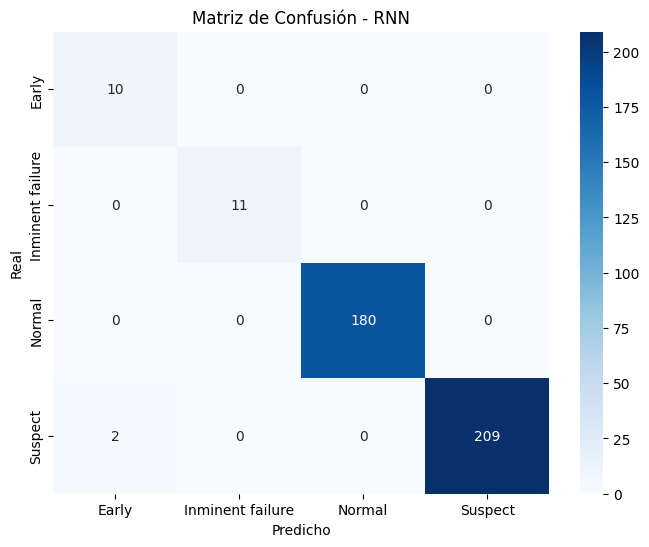

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - RNN")

plt.show()

# LSTM

In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

In [32]:
df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

In [33]:
features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = sorted(df["archivo"].unique())

X = []
y = []

for exp in experimentos:

    bloque = df[df["archivo"] == exp].sort_values("canal")

    matriz = bloque[features].values   # (8 sensores × features)

    X.append(matriz.flatten())         # vectorizar sensores

    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

In [34]:
# estandarizar features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

## Separación del dataset

In [35]:

window = 100

X_seq = []
y_seq = []

for i in range(len(X) - window):

    X_seq.append(X[i:i+window])
    y_seq.append(y[i+window])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)

(2056, 100, 168)


## Codificacion de clases 

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_seq = le.fit_transform(y_seq)

num_classes = len(le.classes_)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    stratify=y_seq,
    random_state=42
)

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    stratify=y_seq,
    random_state=42
)

## Declaración de modelo

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    
    Dropout(0.3),
    
    LSTM(32),
    
    Dense(64, activation="relu"),
    
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Entrenamiento

In [39]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/40


2026-03-27 09:45:27.690712: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 88368000 exceeds 10% of free system memory.
2026-03-27 09:45:27.808244: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 88368000 exceeds 10% of free system memory.


165/165 [==============================] - 5s 14ms/step - loss: 0.2532 - accuracy: 0.9278 - val_loss: 0.0659 - val_accuracy: 0.9787
Epoch 2/40
165/165 [==============================] - 2s 10ms/step - loss: 0.0449 - accuracy: 0.9886 - val_loss: 0.1105 - val_accuracy: 0.9605
Epoch 3/40
165/165 [==============================] - 2s 10ms/step - loss: 0.0403 - accuracy: 0.9878 - val_loss: 0.0348 - val_accuracy: 0.9848
Epoch 4/40
165/165 [==============================] - 2s 10ms/step - loss: 0.0299 - accuracy: 0.9901 - val_loss: 0.0581 - val_accuracy: 0.9818
Epoch 5/40
165/165 [==============================] - 2s 10ms/step - loss: 0.0181 - accuracy: 0.9947 - val_loss: 0.0320 - val_accuracy: 0.9878
Epoch 6/40
165/165 [==============================] - 2s 10ms/step - loss: 0.0189 - accuracy: 0.9939 - val_loss: 0.0399 - val_accuracy: 0.9818
Epoch 7/40
165/165 [==============================] - 2s 13ms/step - loss: 0.0166 - accuracy: 0.9954 - val_loss: 0.0350 - val_accuracy: 0.9848
Epoch 8/40

## Evaluación

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

13/13 [==============================] - 0s 6ms/step
Accuracy: 0.9975728155339806
                  precision    recall  f1-score   support

           Early       0.91      1.00      0.95        10
Inminent failure       1.00      1.00      1.00        11
          Normal       1.00      1.00      1.00       180
         Suspect       1.00      1.00      1.00       211

        accuracy                           1.00       412
       macro avg       0.98      1.00      0.99       412
    weighted avg       1.00      1.00      1.00       412



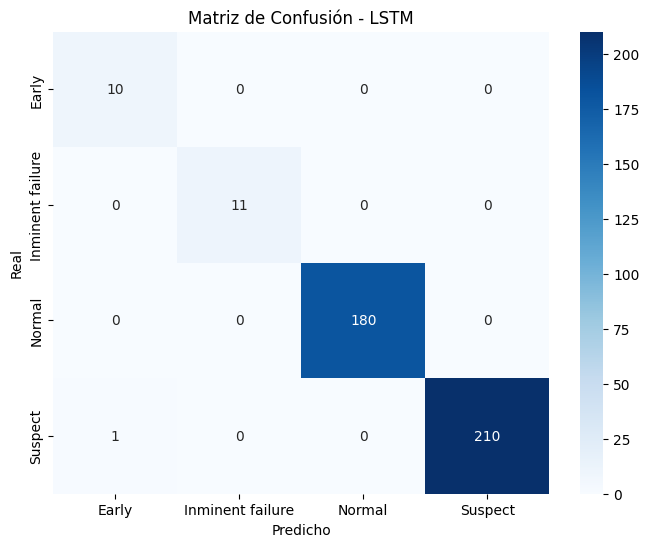

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - LSTM")

plt.show()

# Deep Neural Network

In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

## Separación del dataset

In [44]:
# creacion de tensores
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = df["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df[df["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X.append(matriz)
    
    # target del experimento
    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

print(X.shape)

(2156, 8, 21)


In [45]:
#codificacion de clases 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

num_classes = len(le.classes_)

In [46]:
# escalado de features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(X.shape)

# division en train y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Declaración del modelo

In [53]:
X_train.shape[2]

21

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

num_features = X_train.shape[2]
model = Sequential([

    Dense(128, activation="relu", input_shape=(num_features,)),

    Dense(64, activation="relu"),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(num_classes, activation="softmax")

])

In [49]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Entrenamiento

In [50]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/lib/cuda"

In [51]:
!export XLA_FLAGS=--xla_gpu_cuda_data_dir=/usr/lib/cuda

In [52]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50


ValueError: in user code:

    File "/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py", line 1150, in train_step
        y_pred = self(x, training=True)
    File "/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasi

In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

tf.random.normal([1000,1000]) @ tf.random.normal([1000,1000])

TensorFlow: 2.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<tf.Tensor: shape=(1000, 1000), dtype=float32, numpy=
array([[ 2.0681453e+00, -3.9790595e+00,  3.1033819e+01, ...,
         1.0236137e+01,  5.2362233e-02, -1.7488054e+01],
       [ 1.1501458e+01, -7.4999298e+01,  1.4356805e+01, ...,
        -6.1373112e+01, -1.4905678e+01,  4.6427283e+00],
       [ 8.2927456e+00,  2.0414875e+01, -1.6205723e+01, ...,
         2.9646538e+01,  7.0605202e+00, -3.5695145e+01],
       ...,
       [ 3.2003613e+01,  9.6046629e+00, -6.8210495e+01, ...,
        -2.9567635e+01,  5.8491558e+01, -2.8701713e+00],
       [-1.3942992e+01,  7.2454343e+00, -1.1746420e+02, ...,
         2.2184696e+01,  3.1408421e+01,  1.4719142e+01],
       [-7.0866213e+00,  2.7840712e+01,  5.4760429e+01, ...,
         5.0671363e+00, -1.4376693e+01,  6.7847118e+00]], dtype=float32)>

In [ ]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/lib/cuda"

import os
print(os.environ.get("XLA_FLAGS"))

# luego de esto reetablecer el kernel para que tome la nueva variable de entorno

--xla_gpu_cuda_data_dir=/usr/lib/cuda


## Evaluación

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.9675925925925926
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.92      1.00      0.96        11
          Normal       0.97      0.96      0.97       180
         Suspect       0.97      0.97      0.97       211

        accuracy                           0.97       432
       macro avg       0.96      0.98      0.97       432
    weighted avg       0.97      0.97      0.97       432



In [ ]:
# muestra los valores unicos de y_test para verificar las clases presentes

print(np.unique(y_test))

[0 1 2 3]


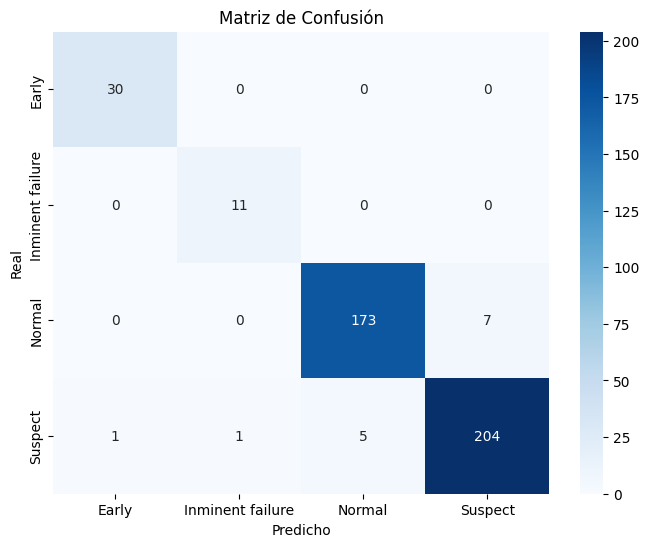

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - DNN")

plt.show()